In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sales_data = pd.read_csv("advertising.csv")
print(sales_data.head())

      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9


In [3]:
print(sales_data.shape)

(200, 4)


In [4]:
print(sales_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None


In [5]:
print(sales_data.isnull().sum())

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


In [6]:
print(sales_data.describe())

               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.100000   19.050000
max    296.400000   49.600000  114.000000   27.000000


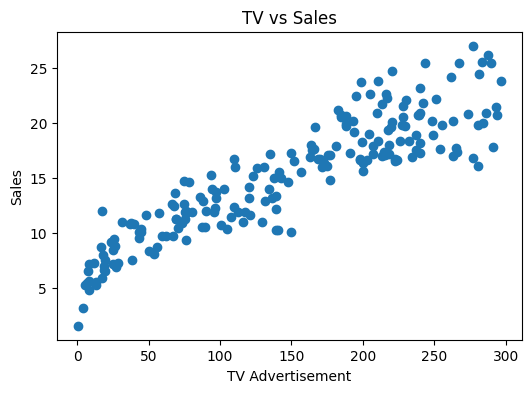

In [7]:
plt.figure(figsize=(6,4))
plt.scatter(sales_data['TV'], sales_data['Sales'])
plt.xlabel("TV Advertisement")
plt.ylabel("Sales")
plt.title("TV vs Sales")
plt.show()

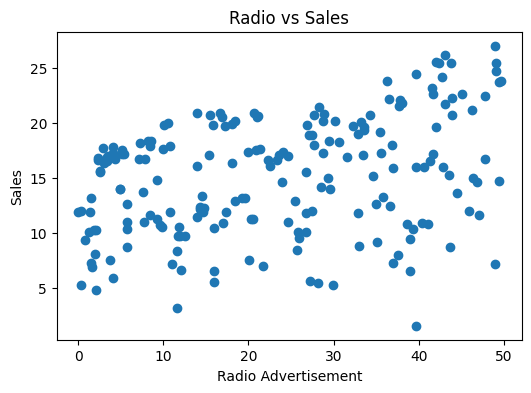

In [8]:
plt.figure(figsize=(6,4))
plt.scatter(sales_data['Radio'], sales_data['Sales'])
plt.xlabel("Radio Advertisement")
plt.ylabel("Sales")
plt.title("Radio vs Sales")
plt.show()

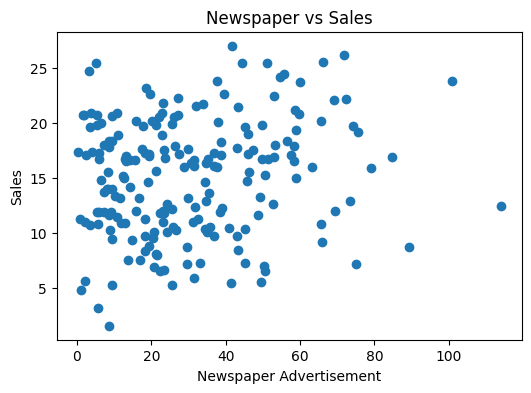

In [9]:
plt.figure(figsize=(6,4))
plt.scatter(sales_data['Newspaper'], sales_data['Sales'])
plt.xlabel("Newspaper Advertisement")
plt.ylabel("Sales")
plt.title("Newspaper vs Sales")
plt.show()

<Axes: ylabel='Frequency'>

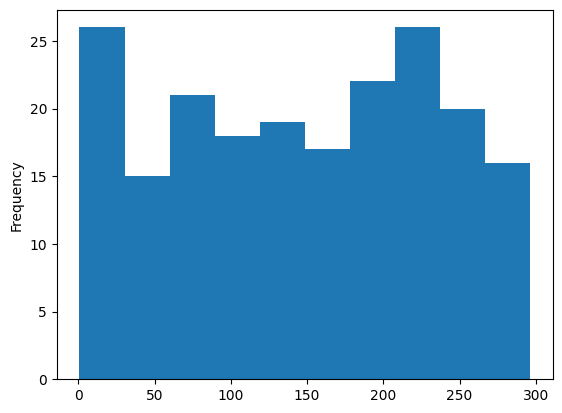

In [10]:
sales_data['TV'].plot.hist(bins=10)

<Axes: xlabel='Radio', ylabel='Frequency'>

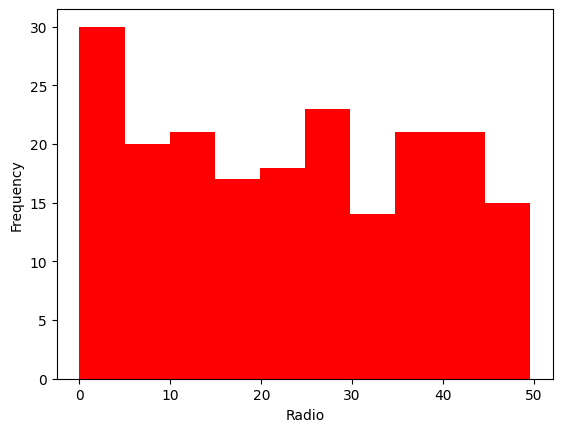

In [11]:
sales_data['Radio'].plot.hist(bins=10, color="red", xlabel="Radio")

<Axes: xlabel='Newspaper', ylabel='Frequency'>

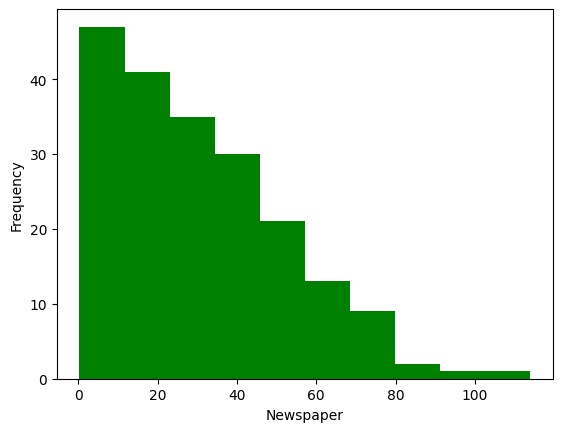

In [12]:
sales_data['Newspaper'].plot.hist(bins=10, color="green", xlabel="Newspaper")

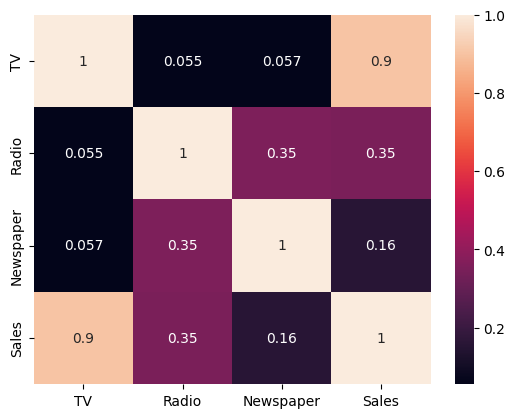

In [13]:
sns.heatmap(sales_data.corr(),annot = True)
plt.show()

In [14]:
X = sales_data[['TV', 'Radio', 'Newspaper']]
y = sales_data['Sales']

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
y_pred = model.predict(X_test)
print(y_pred)

[17.0347724  20.40974033 23.72398873  9.27278518 21.68271879 12.56940161
 21.08119452  8.69035045 17.23701254 16.66657475  8.92396497  8.4817344
 18.2075123   8.06750728 12.64550975 14.93162809  8.12814594 17.89876565
 11.00880637 20.47832788 20.80631846 12.59883297 10.9051829  22.38854775
  9.41796094  7.92506736 20.83908497 13.81520938 10.77080925  7.92682509
 15.95947357 10.63490851 20.80292008 10.43434164 21.5784752  21.18364487
 12.12821771 22.80953262 12.60992766  6.46441252]


In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [20]:
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 1.2748262109549338


In [21]:
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 2.9077569102710896


In [22]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.9059011844150826


In [23]:
comparison = pd.DataFrame({'Actual Sales': y_test,'Predicted Sales': y_pred})
print(comparison.head(10))

     Actual Sales  Predicted Sales
95           16.9        17.034772
15           22.4        20.409740
30           21.4        23.723989
158           7.3         9.272785
128          24.7        21.682719
115          12.6        12.569402
69           22.3        21.081195
170           8.4         8.690350
174          16.5        17.237013
45           16.1        16.666575


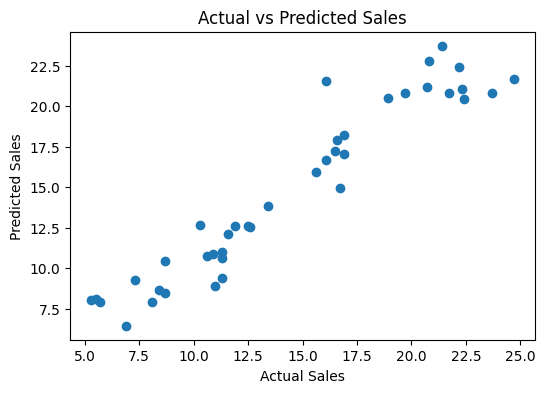

In [24]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

In [25]:
new_data = pd.DataFrame({'TV': [150],'Radio': [25],'Newspaper': [30]})
prediction = model.predict(new_data)
print("Predicted Sales:", prediction[0])

Predicted Sales: 15.544250492282009
